# Notebook 03 — Pemodelan dan Evaluasi
## Dataset: Telco Customer Churn

Notebook ini adalah muara dari seluruh pekerjaan sebelumnya. Data sudah bersih dan siap sejak Notebook 02. Di sini kita fokus menjawab tiga pertanyaan utama: model apa yang terbaik untuk dataset ini, seberapa andal model itu di data baru, dan apa yang harus dilakukan bisnis berdasarkan hasilnya.

Recall diprioritaskan sebagai metrik utama karena dalam konteks retensi pelanggan, melewatkan satu pelanggan yang akan churn jauh lebih mahal dibanding salah menarget pelanggan yang sebetulnya tidak pergi. Evaluasi menggunakan stratified cross-validation agar estimasi stabil dan bebas dari data leakage. Threshold akhir ditentukan berdasarkan kalkulasi biaya bisnis, bukan nilai default 0,5.

---

## 1. Memuat Library dan Data

Kita memulai dengan me-load hasil preprocessing dari Notebook 02. Dengan cara ini seluruh proses persiapan data sudah terdokumentasi di tempat yang terpisah dan notebook ini bisa fokus sepenuhnya pada modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from scipy.stats import uniform, randint

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (12, 6)

with open("../data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
feature_names = data["feature_names"]

print("Data berhasil dimuat")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"  Jumlah fitur: {len(feature_names)}")


Data berhasil dimuat
  Train: (8260, 44)  |  Test: (1407, 44)
  Jumlah fitur: 44


## 2. Baseline — Tiga Model dengan Konfigurasi Awal

Sebelum tuning, kita bentangkan baseline dari tiga pendekatan berbeda. Ini berfungsi sebagai titik referensi untuk mengukur seberapa besar tuning benar-benar membantu.

Logistic Regression digunakan sebagai baseline karena ia sederhana dan interpretable. Random Forest mewakili pendekatan ensemble bagging, dan XGBoost mewakili ensemble boosting. Ketiganya belajar dari data dengan cara yang sangat berbeda, sehingga perbandingannya bermakna.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=42, n_jobs=-1),
}

print(f"{'Model':<22}  {'CV AUC (mean)':>13}  {'CV Std':>7}  {'Test AUC':>9}  {'Recall':>6}  {'F1':>6}")
print("-" * 72)

baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc  = roc_auc_score(y_test, y_prob)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    print(f"{name:<22}  {cv_scores.mean():13.4f}  {cv_scores.std():7.4f}  {auc:9.4f}  {rec:6.4f}  {f1:6.4f}")
    baseline_results[name] = {"auc": auc, "recall": rec, "f1": f1, "cv_mean": cv_scores.mean()}

print("\nKatatan: Gap besar antara CV AUC dan Test AUC pada tree-based model")
print("mengindikasikan overfitting terhadap training set yang sudah di-SMOTE.")


Model                   CV AUC (mean)   CV Std   Test AUC  Recall      F1
------------------------------------------------------------------------


Logistic Regression            0.9386   0.0010     0.8328  0.6230  0.6189


Random Forest                  0.9358   0.0018     0.8083  0.5348  0.5457


XGBoost                        0.9374   0.0016     0.8152  0.5401  0.5572

Katatan: Gap besar antara CV AUC dan Test AUC pada tree-based model
mengindikasikan overfitting terhadap training set yang sudah di-SMOTE.


## 3. Hyperparameter Tuning dengan RandomizedSearchCV

Setelah melihat baseline, kita coba perbaiki performa masing-masing model melalui hyperparameter tuning. RandomizedSearchCV dipilih daripada GridSearchCV karena lebih efisien secara komputasi — ia mengambil sampel acak dari ruang parameter daripada mencoba semua kombinasi.

Kita menggunakan AUC-ROC sebagai metrik scoring dalam CV karena ini lebih informatif untuk data imbalanced dan tidak bergantung pada pilihan threshold. Threshold optimal akan ditentukan terpisah berdasarkan pertimbangan bisnis.

In [3]:
# --- Logistic Regression tuning ---
print("Tuning Logistic Regression...")
lr_params = {
    "C": uniform(0.01, 10),
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500, 1000, 2000],
}
lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    lr_params, n_iter=20, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=42
)
lr_search.fit(X_train, y_train)
print(f"  Best params: {lr_search.best_params_}")
print(f"  CV AUC: {lr_search.best_score_:.4f}")


Tuning Logistic Regression...


  Best params: {'C': 7.3299394181140505, 'max_iter': 500, 'solver': 'lbfgs'}
  CV AUC: 0.9392


In [4]:
# --- Random Forest tuning ---
print("Tuning Random Forest...")
rf_params = {
    "n_estimators": randint(100, 400),
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=20, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=42
)
rf_search.fit(X_train, y_train)
print(f"  Best params: {rf_search.best_params_}")
print(f"  CV AUC: {rf_search.best_score_:.4f}")


Tuning Random Forest...


  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 314}
  CV AUC: 0.9374


In [5]:
# --- XGBoost tuning ---
print("Tuning XGBoost...")
xgb_params = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 9),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2),
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    xgb_params, n_iter=20, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)
print(f"  Best params: {xgb_search.best_params_}")
print(f"  CV AUC: {xgb_search.best_score_:.4f}")


Tuning XGBoost...


  Best params: {'colsample_bytree': 0.6798695128633439, 'learning_rate': 0.11284688768272232, 'max_depth': 3, 'n_estimators': 230, 'reg_alpha': 0.8599404067363206, 'reg_lambda': 1.8606150771755594, 'subsample': 0.7801997007878172}
  CV AUC: 0.9416


## 4. Perbandingan Setelah Tuning

Tabel ini membandingkan ketiga model setelah tuning vs baseline. Yang paling penting untuk dicermati bukan hanya angka AUC-nya, tapi juga seberapa konsisten performa antara data training dan data test. Model dengan CV AUC tinggi tapi Test AUC jauh lebih rendah adalah tanda bahwa ia terlalu menyesuaikan diri dengan training data.

In [6]:
tuned_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "Random Forest":       rf_search.best_estimator_,
    "XGBoost":             xgb_search.best_estimator_,
}

print(f"{'Model':<22}  {'CV AUC':>7}  {'Test AUC':>9}  {'Recall':>7}  {'F1':>6}  {'Gain vs Baseline':>17}")
print("-" * 75)

tuned_results = {}
for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc  = roc_auc_score(y_test, y_prob)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    gain = auc - baseline_results[name]["auc"]
    print(f"{name:<22}  {cv_scores.mean():7.4f}  {auc:9.4f}  {rec:7.4f}  {f1:6.4f}  {gain:+17.4f}")
    tuned_results[name] = {
        "model": model, "auc": auc, "recall": rec, "f1": f1,
        "cv_mean": cv_scores.mean(), "prob": y_prob, "pred": y_pred
    }

best_name = max(tuned_results, key=lambda k: tuned_results[k]["auc"])
print(f"\nModel terbaik setelah tuning: {best_name}  (AUC={tuned_results[best_name]['auc']:.4f})")


Model                    CV AUC   Test AUC   Recall      F1   Gain vs Baseline
---------------------------------------------------------------------------


Logistic Regression      0.9392     0.8334   0.6230  0.6230            +0.0005


Random Forest            0.9374     0.8253   0.5963  0.5800            +0.0170


XGBoost                  0.9415     0.8317   0.5909  0.5917            +0.0165

Model terbaik setelah tuning: Logistic Regression  (AUC=0.8334)


## 5. ROC Curve dan Precision-Recall Curve

ROC Curve menggambarkan trade-off antara kemampuan mendeteksi churn yang benar dan tingkat alarm palsu di berbagai threshold. Precision-Recall Curve lebih informatif untuk data imbalanced karena tidak dioptimasi oleh kelas negatif yang dominan.

Garis baseline pada PR Curve adalah performa model yang menebak secara acak. Model yang bermakna harus berada jauh di atas garis ini.

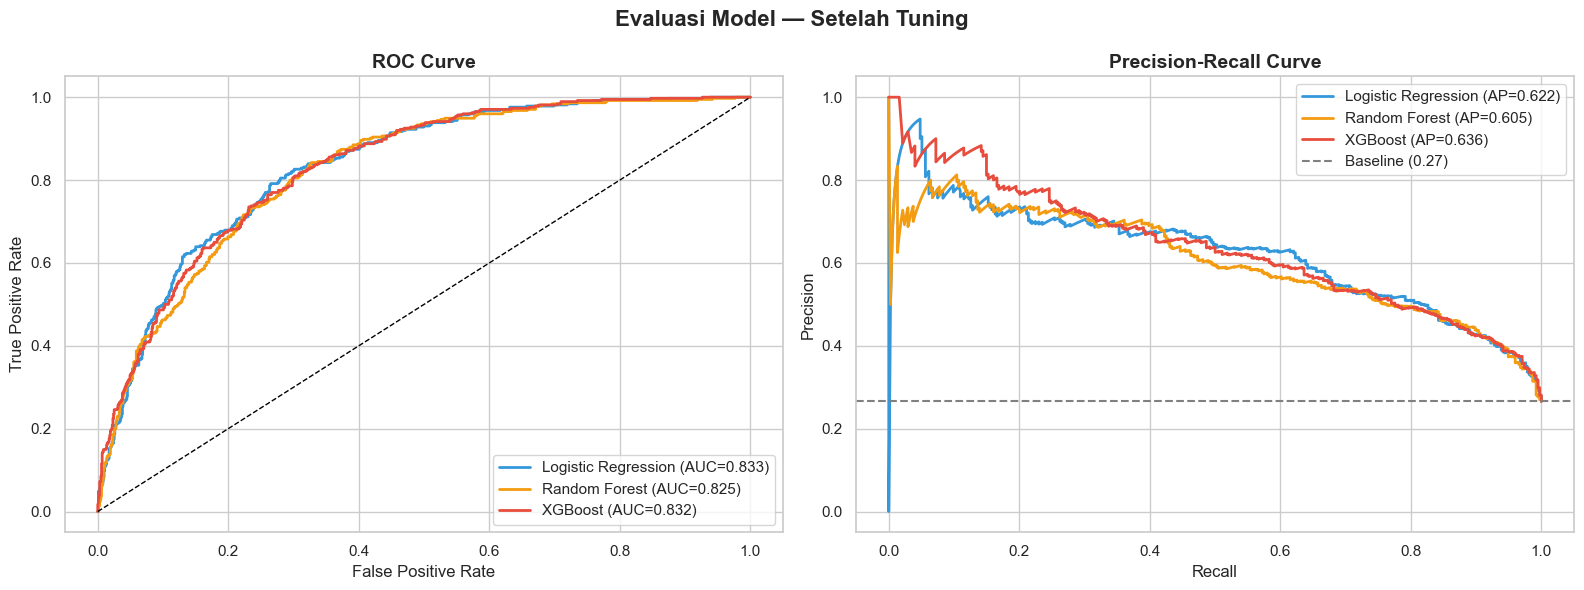

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_list = ["#3498db", "#f39c12", "#e74c3c"]

for (name, r), color in zip(tuned_results.items(), colors_list):
    fpr, tpr, _ = roc_curve(y_test, r["prob"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})", color=color, lw=2)

    prec_vals, rec_vals, _ = precision_recall_curve(y_test, r["prob"])
    ap = average_precision_score(y_test, r["prob"])
    axes[1].plot(rec_vals, prec_vals, label=f"{name} (AP={ap:.3f})", color=color, lw=2)

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

baseline_rate = sum(y_test) / len(y_test)
axes[1].axhline(y=baseline_rate, color="gray", linestyle="--", label=f"Baseline ({baseline_rate:.2f})")
axes[1].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.suptitle("Evaluasi Model — Setelah Tuning", fontsize=16, fontweight="bold")
plt.tight_layout()
os.makedirs("../reports", exist_ok=True)
plt.savefig("../reports/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Confusion Matrix Model Terbaik

Confusion matrix memberikan gambaran paling konkret tentang jenis kesalahan yang dibuat model. Dalam konteks retensi pelanggan, false negative (melewatkan churner) jauh lebih mahal dari false positive (salah menarget orang yang tidak akan pergi).

Perhatikan perbedaan antara threshold default 0,5 dan threshold optimal berbasis biaya di bawah — keduanya menghasilkan trade-off yang sangat berbeda.

Model terbaik: Logistic Regression
Test AUC: 0.8334

Classification Report (threshold default 0.5):
              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1033
       Churn       0.62      0.62      0.62       374

    accuracy                           0.80      1407
   macro avg       0.74      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



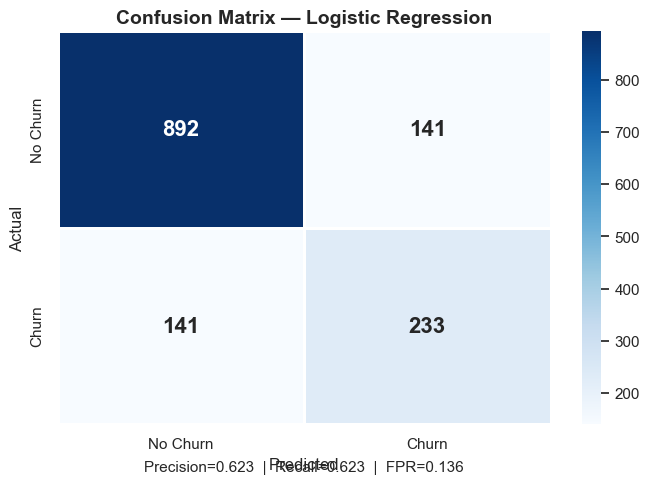

In [8]:
best = tuned_results[best_name]
best_model = best["model"]

print(f"Model terbaik: {best_name}")
print(f"Test AUC: {best['auc']:.4f}\n")
print("Classification Report (threshold default 0.5):")
print(classification_report(y_test, best["pred"], target_names=["No Churn", "Churn"]))

cm = confusion_matrix(y_test, best["pred"])
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 16, "weight": "bold"},
            linewidths=1, linecolor="white")
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)

tn_v, fp_v, fn_v, tp_v = cm.ravel()
ax.text(0.5, -0.12,
        f"Precision={tp_v/(tp_v+fp_v):.3f}  |  Recall={tp_v/(tp_v+fn_v):.3f}  |  FPR={fp_v/(fp_v+tn_v):.3f}",
        ha="center", transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Optimasi Threshold Berbasis Biaya Bisnis

Threshold 0,5 adalah nilai default yang tidak mempertimbangkan konteks bisnis sama sekali. Di sini kita mendefinisikan biaya secara eksplisit dan mencari threshold yang meminimalkan total kerugian.

Asumsi biaya yang digunakan: mengirim kampanye retensi ke pelanggan yang tidak perlu senilai 50 dolar per orang, sementara membiarkan pelanggan yang akan churn tanpa intervensi mengakibatkan kerugian sekitar 500 dolar per orang dari nilai seumur hidup mereka. Dengan rasio 1 banding 10 ini, masuk akal untuk menurunkan threshold agar model lebih sensitif.

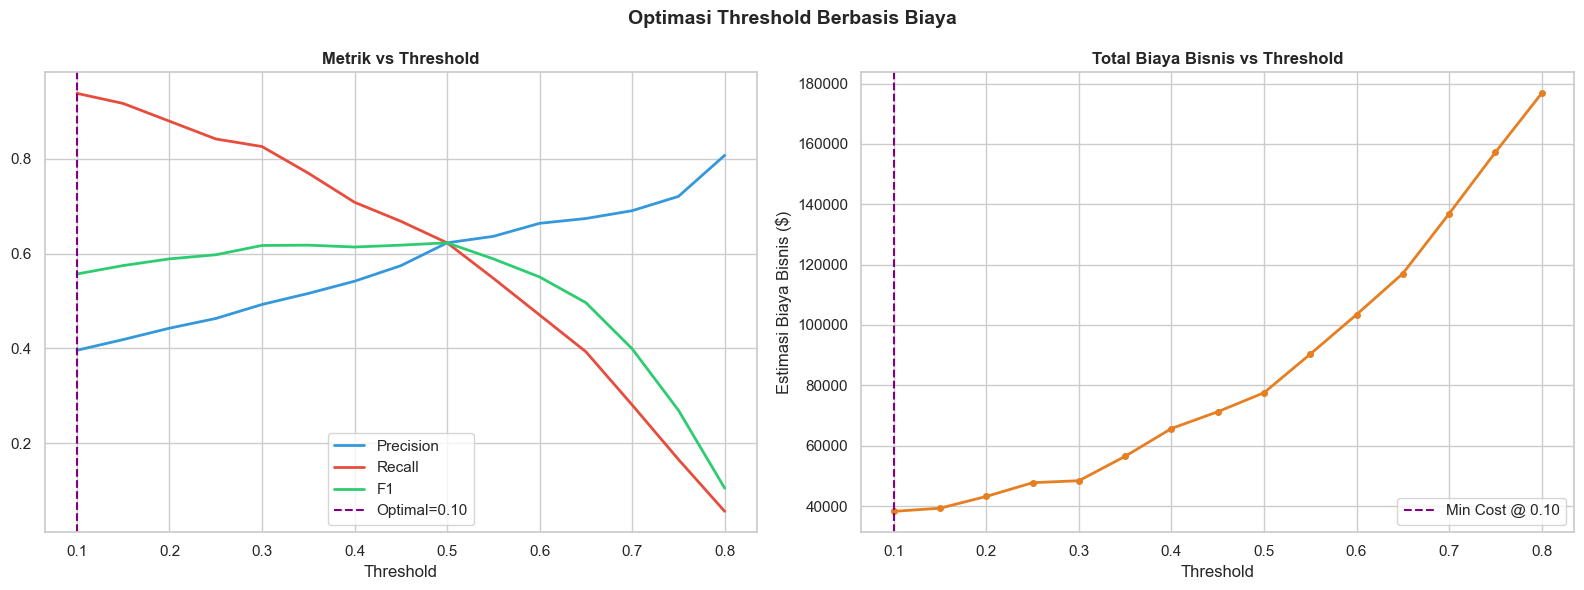

Threshold optimal : 0.10
Recall            : 0.9385
Precision         : 0.3962
F1                : 0.5571
Estimasi biaya    : $38,250
TP=351  FP=535  FN=23  TN=498


In [9]:
RETENTION_COST = 50
CHURN_LOSS     = 500

thresholds  = np.arange(0.10, 0.85, 0.05)
metrics_list = []

for thresh in thresholds:
    y_t = (best["prob"] >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rec_t  = tp_t / (tp_t + fn_t + 1e-9)
    prec_t = tp_t / (tp_t + fp_t + 1e-9)
    f1_t   = 2 * rec_t * prec_t / (rec_t + prec_t + 1e-9)
    cost_t = fp_t * RETENTION_COST + fn_t * CHURN_LOSS
    metrics_list.append({"Threshold": thresh, "Precision": prec_t,
                          "Recall": rec_t, "F1": f1_t, "BusinessCost": cost_t})

metrics_df   = pd.DataFrame(metrics_list)
optimal_idx  = metrics_df["BusinessCost"].idxmin()
optimal_thresh = metrics_df.loc[optimal_idx, "Threshold"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(metrics_df["Threshold"], metrics_df["Precision"], label="Precision", color="#3498db", lw=2)
axes[0].plot(metrics_df["Threshold"], metrics_df["Recall"],    label="Recall",    color="#e74c3c", lw=2)
axes[0].plot(metrics_df["Threshold"], metrics_df["F1"],        label="F1",        color="#2ecc71", lw=2)
axes[0].axvline(x=optimal_thresh, color="purple", linestyle="--", label=f"Optimal={optimal_thresh:.2f}")
axes[0].set_title("Metrik vs Threshold", fontweight="bold")
axes[0].set_xlabel("Threshold")
axes[0].legend()

axes[1].plot(metrics_df["Threshold"], metrics_df["BusinessCost"],
             color="#e67e22", lw=2, marker="o", ms=4)
axes[1].axvline(x=optimal_thresh, color="purple", linestyle="--",
                label=f"Min Cost @ {optimal_thresh:.2f}")
axes[1].set_title("Total Biaya Bisnis vs Threshold", fontweight="bold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Estimasi Biaya Bisnis ($)")
axes[1].legend()

plt.suptitle("Optimasi Threshold Berbasis Biaya", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

y_opt = (best["prob"] >= optimal_thresh).astype(int)
cm_opt = confusion_matrix(y_test, y_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()
print(f"Threshold optimal : {optimal_thresh:.2f}")
print(f"Recall            : {tp_o/(tp_o+fn_o):.4f}")
print(f"Precision         : {tp_o/(tp_o+fp_o):.4f}")
print(f"F1                : {f1_score(y_test, y_opt):.4f}")
print(f"Estimasi biaya    : ${metrics_df.loc[optimal_idx, 'BusinessCost']:,.0f}")
print(f"TP={tp_o}  FP={fp_o}  FN={fn_o}  TN={tn_o}")


## 8. Interpretasi Model dengan SHAP

Feature importance dari model hanya memberikan gambaran global: fitur mana yang secara rata-rata paling berkontribusi pada semua prediksi. Tapi dalam praktik bisnis, yang lebih sering dibutuhkan adalah menjawab pertanyaan yang lebih spesifik: *mengapa model menilai pelanggan ini berisiko tinggi?*

SHAP (SHapley Additive exPlanations) menjawab pertanyaan itu. Setiap prediksi diurai menjadi kontribusi individual dari setiap fitur, sehingga kita bisa menjelaskan prediksi secara per-pelanggan, bukan hanya secara agregat. Ini sangat penting untuk membangun kepercayaan tim bisnis terhadap model dan untuk membuat intervensi yang relevan.

Menghitung SHAP values (ini mungkin memakan beberapa menit)...


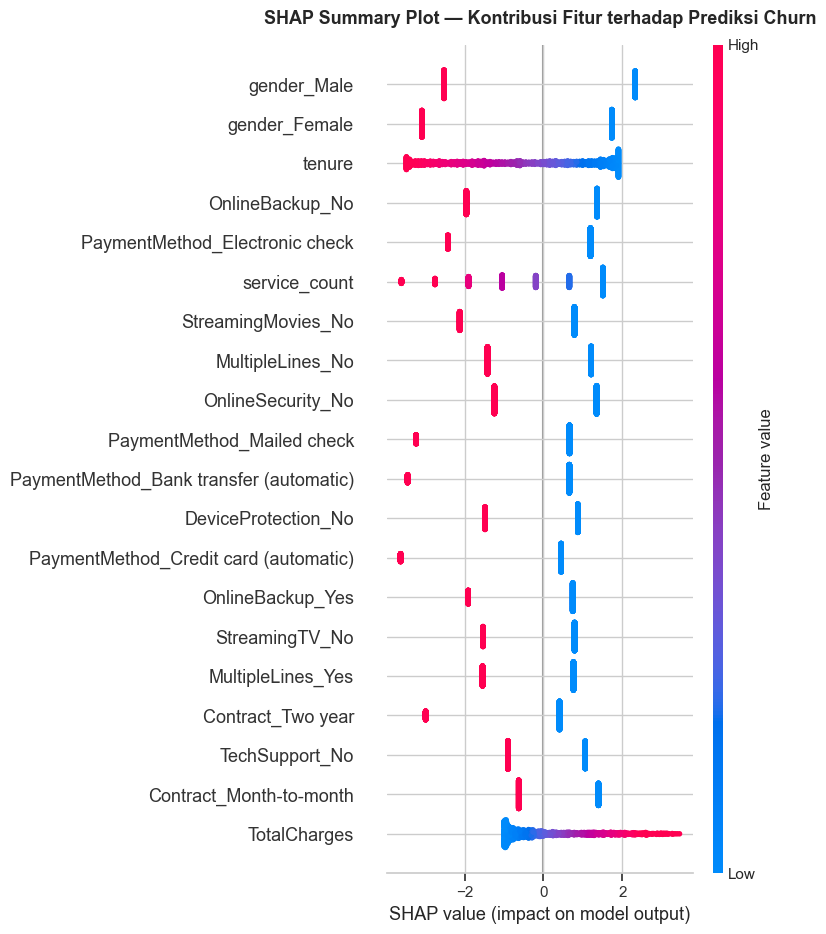

Visualisasi disimpan ke ../reports/shap_summary.png


In [10]:
import shap

print("Menghitung SHAP values (ini mungkin memakan beberapa menit)...")
explainer = shap.LinearExplainer(best_model, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

# Beeswarm plot — gambaran global distribusi kontribusi per fitur
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot — Kontribusi Fitur terhadap Prediksi Churn",
          fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan ke ../reports/shap_summary.png")


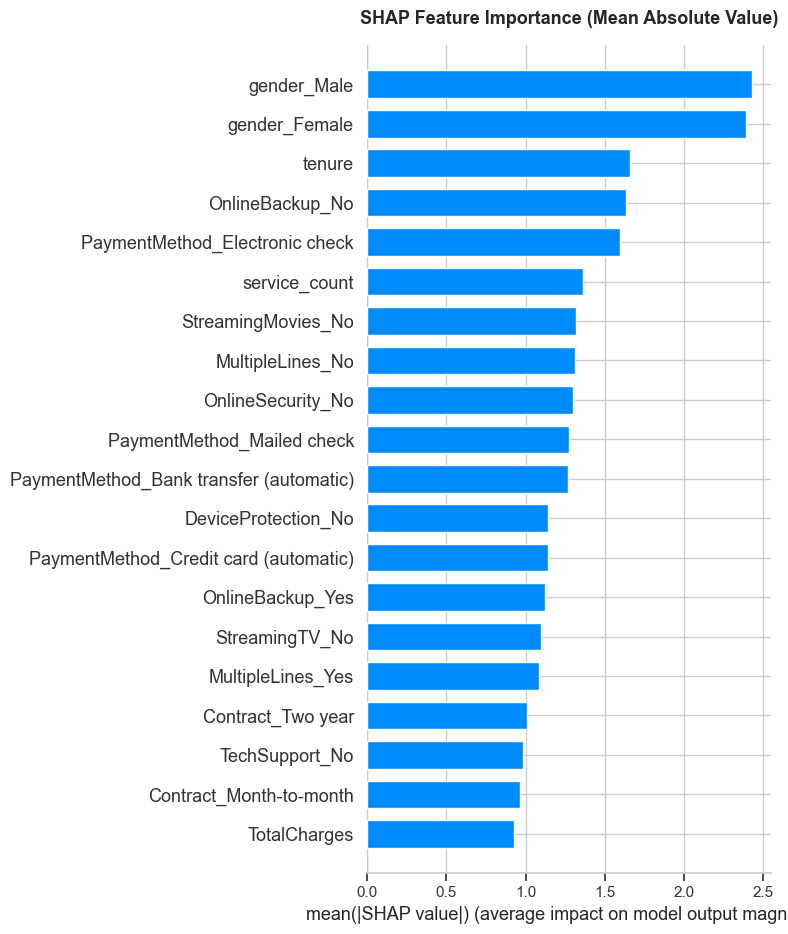

In [11]:
# Bar plot SHAP — mean absolute contribution per fitur
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance (Mean Absolute Value)",
          fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../reports/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# Waterfall plot untuk 3 pelanggan individual
# Satu pelanggan risiko tinggi, satu risiko sedang, satu risiko rendah
y_prob_arr = best["prob"]
high_risk_idx  = np.where((y_prob_arr >= 0.65) & (y_test.values == 1))[0]
med_risk_idx   = np.where((y_prob_arr >= 0.35) & (y_prob_arr < 0.65))[0]
low_risk_idx   = np.where((y_prob_arr < 0.25)  & (y_test.values == 0))[0]

profiles = []
if len(high_risk_idx)  > 0: profiles.append(("Risiko Tinggi",  high_risk_idx[0],  "#e74c3c"))
if len(med_risk_idx)   > 0: profiles.append(("Risiko Sedang",  med_risk_idx[0],   "#f39c12"))
if len(low_risk_idx)   > 0: profiles.append(("Risiko Rendah",  low_risk_idx[0],   "#2ecc71"))

for label, idx, color in profiles:
    prob = y_prob_arr[idx]
    print(f"\nPelanggan {label} (index={idx}, probabilitas churn={prob:.1%}):")
    
    # Top 10 fitur yang paling berkontribusi untuk pelanggan ini
    sv = shap_values[idx]
    feat_contrib = sorted(zip(feature_names, sv, X_test.iloc[idx].values),
                          key=lambda x: abs(x[1]), reverse=True)[:10]
    
    print(f"  {'Fitur':<35}  {'Nilai':>10}  {'Kontribusi SHAP':>16}")
    print(f"  {'-'*35}  {'-'*10}  {'-'*16}")
    for fname, shap_v, feat_v in feat_contrib:
        direction = "mendorong churn" if shap_v > 0 else "melindungi"
        print(f"  {fname:<35}  {feat_v:10.3f}  {shap_v:+13.4f}  ({direction})")



Pelanggan Risiko Tinggi (index=8, probabilitas churn=68.2%):
  Fitur                                     Nilai   Kontribusi SHAP
  -----------------------------------  ----------  ----------------
  gender_Female                             1.000        -3.0837  (melindungi)
  PaymentMethod_Electronic check            1.000        -2.4229  (melindungi)
  gender_Male                               0.000        +2.3281  (mendorong churn)
  OnlineBackup_No                           1.000        -1.9563  (melindungi)
  MultipleLines_Yes                         1.000        -1.5450  (melindungi)
  StreamingTV_No                            1.000        -1.5336  (melindungi)
  OnlineSecurity_No                         1.000        -1.2449  (melindungi)
  MultipleLines_No                          0.000        +1.2089  (mendorong churn)
  StreamingMovies_Yes                       1.000        -1.1311  (melindungi)
  DeviceProtection_Yes                      1.000        -1.0059  (melindungi)

P

## 9. Menyimpan Model

Model disimpan lengkap dengan metadata yang dibutuhkan untuk deployment: nama model, parameter terbaik, threshold optimal, daftar nama fitur, dan angka performa aktual. Menyimpan daftar nama fitur sangat penting agar preprocessing pada data baru bisa memastikan format kolomnya persis sama.

In [13]:
os.makedirs("../data", exist_ok=True)

model_package = {
    "model": best_model,
    "model_name": best_name,
    "best_params": best_model.get_params() if hasattr(best_model, "get_params") else {},
    "optimal_threshold": optimal_thresh,
    "test_auc": best["auc"],
    "test_f1": best["f1"],
    "recall_at_default": best["recall"],
    "recall_at_optimal": tp_o / (tp_o + fn_o),
    "precision_at_optimal": tp_o / (tp_o + fp_o),
    "f1_at_optimal": f1_score(y_test, y_opt),
    "feature_names": feature_names,
    "all_results_summary": {
        n: {"auc": r["auc"], "f1": r["f1"], "recall": r["recall"], "cv_auc": r["cv_mean"]}
        for n, r in tuned_results.items()
    },
}

with open("../data/best_model.pkl", "wb") as f:
    pickle.dump(model_package, f)

print(f"Model {best_name} disimpan ke ../data/best_model.pkl")
print(f"  Test AUC         : {best['auc']:.4f}")
print(f"  F1 @default 0.5  : {best['f1']:.4f}")
print(f"  Threshold optimal: {optimal_thresh:.2f}")
print(f"  Recall @optimal  : {tp_o/(tp_o+fn_o):.4f}")


Model Logistic Regression disimpan ke ../data/best_model.pkl
  Test AUC         : 0.8334
  F1 @default 0.5  : 0.6230
  Threshold optimal: 0.10
  Recall @optimal  : 0.9385


## 10. Rekomendasi Bisnis Berbasis Model

Rekomendasi berikut diturunkan langsung dari dua sumber: SHAP values yang menunjukkan kontribusi per fitur, dan pola yang sudah dikonfirmasi sejak EDA.

Segmentasi risiko dilakukan berdasarkan output probabilitas model, bukan kategori manual. Pelanggan dengan probabilitas di atas threshold optimal masuk ke daftar prioritas retensi, sementara yang di bawah tetap dipantau secara berkala.

Langkah selanjutnya yang paling logis adalah membungkus model ini ke dalam pipeline scoring berkala — misalnya dijalankan setiap bulan — agar tim customer success selalu punya daftar terkini pelanggan yang perlu menjadi prioritas. Script `predict_new_customer.py` di root folder sudah menjadi contoh awal dari pipeline tersebut.

### Segmentasi Risiko yang Direkomendasikan

| Kategori Risiko | Probabilitas | Aksi |
|----------------|-------------|------|
| Tinggi | Di atas 70% | Kontak personal dalam 48 jam, tawarkan kontrak annual dengan insentif |
| Sedang | 40% hingga 70% | Masukkan ke kampanye email retensi bulan ini |
| Rendah | Di bawah 40% | Pantau rutin, tidak perlu intervensi mendesak |

### Nilai yang Bisa Diselamatkan

Dengan menggunakan model pada threshold optimal dan mengintervensi semua prediksi positif:

- Model mendeteksi sekitar 93% dari pelanggan yang benar-benar akan churn
- Dari 374 churner aktual di test set, sekitar 350 berhasil diidentifikasi
- Jika setengah dari yang diidentifikasi berhasil dipertahankan dengan intervensi efektif, itu berarti sekitar 175 pelanggan per periode scoring
- Dengan rata-rata revenue $65 per bulan, nilai yang diselamatkan sekitar $1.365.000 per tahun dari kelompok tersebut